# U.S. Pharmaceutical Drug Shortage Risk Dashboard
## An Interactive Tutorial Using Plotly Dash and Dash Bootstrap Components

|**Author:** Nikhil Jain | **Course:** SIADS 521 — Visual Exploration of Data  | **Date:** March 2026|

## Introduction

Drug shortages are not random events — they follow structural patterns
tied to manufacturing concentration, regulatory failures, and demand
volatility. This tutorial demonstrates how to build an interactive
supply chain risk dashboard using **Plotly Dash** and **Dash Bootstrap
Components**, using FDA drug shortage data as our lens.

By the end of this tutorial, you will know how to:
- Fetch and clean data from a public API programmatically
- Build a multi-panel interactive dashboard in Python
- Wire interactive controls to multiple charts simultaneously
- Deploy your dashboard publicly on Render.com

The dataset spans drug shortages reported to the FDA from 2010–2026,
covering therapeutic categories, manufacturers, root causes, and
resolution status — with a particular focus on how supply chain
vulnerability evolved before and after COVID-19.

### About the Data:
The data was fetched from FDA website where this data has been open-sourced. Link to openFDA database: https://open.fda.gov/apis/drug/drugshortages/

This tutorial demonstrates how to build an interactive multi-panel dashboard
that answers four key questions about pharmaceutical supply chain risk:
1. **When** did drug shortages occur and how have they trended over time?
2. **Who** — which companies and therapeutic categories are most affected?
3. **Why** — what are the root causes of shortages?
4. **How long** — how persistent are shortages once they begin?

## 2. Visualization Library

### 2.1 What is Plotly Dash?
Plotly Dash is an open-source Python framework used for building analytical web applications and interactive dashboards without needing JavaScript. Built on top of Plotly.js, React, and Flask, it is designed for data scientists to easily create data-driven visualizations with UI components like dropdowns, sliders, and graphs. The strongest part of Plotly Dash is that it is production-grade and is widely adopted in the industry for production ready and easy-to-use dashboard deployment.

### 2.2 Why Dash v/s Alteratives (Streamlit, Panel, Voila):
Dash is best for complex, highly customizable, enterprise-grade, multi-page data applications, while alternatives like Streamlit and Panel are better suited for rapid prototyping and simpler dashboards. Dash offers superior control over UI/UX using React, whereas Streamlit offers unmatched speed in turning scripts into apps, and Panel offers high flexibility in Jupyter environments.

- Strengths: Highly customizable, production-ready, backend flexibility, and excellent for complex, interactive analytics.
- Use Cases: Large, customized enterprise dashboards requiring high scalability.
- Downside: Steeper learning curve; requires some understanding of React/web development for advanced customization.

### 2.3 Declarative or Procedural?
Dash is primarily declarative and reactive.  It is designed for building data visualization web applications by describing what the application layout and components should look like and how they should react.
While the overall paradigm is declarative, the functions you write within your callbacks to process data (like pandas operations) are written in an imperative or procedural style, but the management of data between callbacks is handled declaratively.

#### 2.3.1 Callbacks in Dash
The UI of Dash can be connected to functions, where data filtering, logics and graphical plotting using plotly is carried out using callbacks. Callbacks helps connect input and state managed from front end (inputs, sliders, date picker and other components) to output produced from the functions, where callback decorator is added on top of function definition.

```
@callback(
    Output('line-chart', 'figure'),  # what changes
    Input('year-slider', 'value')    # what triggers it
)
def update_line_chart(year_range):
    # filter data based on input
    # return updated figure
    return fig
```
### 2.4 Dash Bootstrap Components
To reduce the complexity with setting up the user interface, dash provides an integration with the bootstrap library for front end building where pre-designed components can be accessed from the dash-bootstrap-components library/package
In this tutorial we use the `FLATLY` theme — a clean, modern flat design suitable for data dashboards. Themes are passed at app initialization:
Layout is managed using `dbc.Container, dbc.Row, dbc.Col, dbc.Card to create the skeleton of the page`.  The controls and dynamic elements are available in the dcc from Dash like `dcc.Graph, dcc.Dropdown, dcc.DatePickerRange`

### 2.5 Installation
Install the following packages:
- plotly: the plotting library (similar to matplotlib, altair, seaborn)
- dash: the deployment package to deploy the plots on a visual environment
- dash_bootstrap_components: to give visual appeal using bootstrap components (UI components)
- jupyter-dash: to run dash in jupyter notebook

`pip install dash plotly dash-bootstrap-components pandas numpy nbformat jupyter-dash`

Or install from the project requirements file:
```bash
pip install -r requirements.txt
````



### 2.6 Limitations:
- Learning curve is steep if not familiar with React and front-end development as how to style the front-end is critical while designing production ready dashboard
- Dash apps require a running Python server — unlike static HTML pages
- Callbacks can get complex to debug in large dashboards

*Note: These limitations are based on direct experience building this
dashboard. Performance and streaming limitations exist but were not
encountered at this dataset scale (1,686 records).*


## 3. Visualization Techniques:
#### Techique 1: Line Chart
- Used when x data is categorical and y data is quantitative. Generally for time series data, line charts are the best because they allow to easily visualize the trends in the data.
- In this project we have used line chart to plot trends of shortages over years.
-In the dashboard, the line chart is linked to the date range picker — allowing users to zoom into specific time windows and observe how **shortage patterns changed before and after COVID-19**

#### Technique 2: Bar Chart (Vertical & Horizontal)
- Used when one of the data is categorical (typically when data is nominal) and other data is quantitative and we need to compare the difference between the quantum of y for each of the categorical variable.
- In this project, we have used bar charts to plot count of shortages against various categorical variables like Shortage reasons, Companies, Brand names, Dosage form, availability, etc.
-The bar chart is linked to the categorical dropdown — allowing users to switch between company names, therapeutic categories, dosage forms, and brand names dynamically. Horizontal orientation was chosen when category labels are long, preventing overlapping x-axis text.

#### Technique 3: Box Plot
- Used when we need to understand the distribution of a quantitative  variable across different categories. Box plots show the median, interquartile range (IQR), and outliers simultaneously — making them ideal for comparing spread and skewness across groups.
- In this project, we use box plots to visualize the distribution of shortage duration (in days) across different categorical variables like therapeutic categories and companies — revealing which **categories have the most chronic and unpredictable shortages**.
- In the dashboard, the box plot is linked to both the date range picker and categorical dropdown — allowing users to compare duration distributions across different groupings and time windows.

#### Technique 4: Scatter Plot
- Used when we need to understand the relationship between two quantitative variables. Scatter plots reveal correlations, clusters, and outliers that are invisible in aggregated charts.
- In this project, we use a scatter plot to plot median shortage duration (y-axis) against number of shortages (x-axis) for each category in the selected categorical variable — **creating a risk quadrant where entities with both high frequency and long duration represent the highest supply chain risk.**
- In the dashboard, the scatter plot is linked to both the date range picker and categorical dropdown — allowing users to identify which companies or therapeutic categories fall into the **high-risk quadrant under different time windows.**


### 3.2 How These Visualizations Complement Each Other

The four visualization types work together to tell a sequential supply
chain risk story — each answering a progressively deeper question:

- **Line chart** establishes the temporal context — **when** did shortages
  occur and how has the trend evolved?
- **Bar chart** identifies the most affected entities — **who** and **what**
  is most impacted across categories, companies, and dosage forms?
- **Box plot** reveals duration and persistence — **how long** do shortages
  last, and which categories are chronically affected vs. acutely disrupted?
- **Scatter plot** synthesizes frequency and duration into a single risk
  view — **which** entities are simultaneously high-frequency and
  long-duration, representing the most structurally vulnerable parts of
  the supply chain?

All four charts share the same two interactive controls — a date range
picker and a categorical dropdown wherein every filter the user applies
updates all panels simultaneously. This interactivity allows users
to slice the data by time period and category and observe how the entire
risk picture shifts together, rather than viewing each chart in isolation.

# Section 4: Demonstration

## Imports
#### Importing all the essential libraries required in the code: pandas, numpy, plotly, dash, datetime, dash-bootstrap-components and jupyter_dash

In [34]:
# !pip install dash dash_bootstrap_components jupyter_dash joblib

In [20]:
import pandas as pd
import numpy as np
import requests
import math
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import datetime
from dash import Dash, dcc, html, callback, Input, Output, State
import dash_bootstrap_components as dbc
from jupyter_dash import JupyterDash
from joblib import Memory

### 4.1 About the Dataset
The data was fetched from FDA website where this data has been open-sourced. Link to openFDA database: https://open.fda.gov/apis/drug/drugshortages/
The dataset contains 1686 records, 19 columns with reported shortages from 2010 to 2026.
The dataset contains timeseries (date when shortage was first reported and later updated), categorical (therapeutic category, dosage form, company name, brand name) and root cause related fields (shortage reason).
#### Limitation of the dataset:
- The update_date is the date when the record was revisited by FDA to update the status of the shortage, the status if shows current, does not mean that the drug is available now. For that Availabilility column needs to be checked. The field (Created) `shortage_duration` hence only applies to open shortages as the data doesn't tell when the shortage was fulfilled if the updated availability status has turned to "Available"  as data is not collected realtime.
-FDA keeps shortage records marked as "Current" even when drugs have returned to market, meaning status alone is not adequate

### 4.2 Data Fetching

#### 4.2.1 OpenFDA API
OpenFDA API can be accessed by importing `requests` and get a json response by hitting the API URL: `https://api.fda.gov/drug/{endpoint}?limit={limit}&skip={skip}` where endpoint = shortages.json
The API returns a JSON response with two keys — `meta` (containing  total record count) and `results` (containing the actual records) —  which is then converted to a pandas DataFrame.

#### 4.2.2 Pagination  
Only 1000 records can be accessed with one request. To access all records (1686 records), multiple requests were sent to the API URL, and accessed 1000 records at a time, skipping the previously fetched records using skip variable in the API query.

#### 4.2.3 Caching with Joblib
Caching was implemented using Memory cache with Joblib library. Caching improves the efficiecy of the code as the data is not required to be fetched in every session as it is stored locally in the cache folder for quick access. Cached data is stored in the `cache/` directory locally and is excluded from version control via `.gitignore`.

The following function implements pagination and caching to fetch  the complete dataset in two API calls:

In [21]:
# get_FDA_data function to fetch data from FDA website


memory = Memory('../cache/features/', verbose=1)
@memory.cache
def get_FDA_data(endpoint, limit = 1000):
    """
    Fetches data from the FDA API for a specified endpoint and limit.

    Input:
    - endpoint: The specific FDA API endpoint to query (e.g., 'shortages', 'event').
    - limit: The maximum number of records to retrieve (default is 1000).
    - endpoints:  drug shortages: shortages.json

    Output: returns a list of records from the FDA API response.
    """
    #Store all records in a list
    all_records = []
    skip = 0 # Number of records to skip for pagination
    num_records = 0 # Total number of records available (to be updated after the first API call)

    while True:
        api_url = f"https://api.fda.gov/drug/{endpoint}?limit={limit}&skip={skip}"
        response = requests.get(api_url)

        if response.status_code == 200:
            try:
                data = response.json()
                # Update total number of records available after the first API call
                if skip == 0:
                    # Number of records to be retrieved:
                    num_records = data.get('meta',{}).get('results', {}).get('total', 0)
                    print(f"Total records available: {num_records}")

                    # Number of queries needed to retrieve all records:
                    num_queries = math.ceil(num_records / limit)
                    print(f"Number of queries needed: {num_queries}")

                # Fetch the records and add to the list
                records = data.get('results', [])
                all_records.extend(records)
                print(f"Fetched records {skip + 1} to {skip + len(records)} of {num_records}")

            except ValueError:
                print("Error: Response content is not valid JSON.")

        else:
                print("Please check your endpoint and try again.")
        skip += limit
        if skip >= num_records:
            break

    return all_records

In [22]:
# Calling the above function:
# Fetch data and convert to DataFrame
records = get_FDA_data('shortages.json', limit=1000)
df = pd.DataFrame(records)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Dataset shape: (1685, 19)
Columns: ['update_type', 'initial_posting_date', 'package_ndc', 'generic_name', 'contact_info', 'availability', 'openfda', 'update_date', 'therapeutic_category', 'dosage_form', 'presentation', 'company_name', 'status', 'related_info', 'discontinued_date', 'shortage_reason', 'related_info_link', 'change_date', 'resolved_note']


### 4.3 Data Cleaning

#### 4.3.1 Extracting from Nested openfda Column
'brand_name' and 'route' were extracted from the nested 'openfda'
column by applying a lambda function to each row using '.apply()',
unwrapping the dictionary and storing values in two new columns.

#### 4.3.2 Column Selection
The following columns were dropped as they were not relevant to the
analysis: 'package_ndc', 'contact_info', 'related_info', 'presentation',
'change_date', 'resolved_note', 'related_info_link', and 'openfda'.
For `therapeutic_category', only the first category from the list was
retained, as most drugs belonged primarily to one therapeutic area.

#### 4.3.3 Date Parsing
Three columns — 'initial_posting_date', 'update_date', and
'discontinued_date' — were parsed from string to datetime format
using 'pd.to_datetime()'.

#### 4.3.4 Handling Nulls
Nulls in 'shortage_reason' and 'availability were found to be
structurally explained by the 'status' column rather than data quality
issues. Specifically, 'shortage_reason' was null when: (1) the drug
had returned to market and was now available, (2) the drug was being
discontinued, or (3) the shortage had been resolved. These nulls were
filled with contextually appropriate labels based on the 'availability'
and 'status' columns.

#### 4.3.5 Fixing Typos
The 'availability' column contained two typo variants of 'Limited
Availability' — 'Limited Availabiltiy' and 'Limited Availablity' —
both of which were corrected using `.str.replace()`.

#### 4.3.6 Feature Engineering
Two new columns were created: 'year', extracted from
'initial_posting_date' using `.dt.year`; and 'duration_days',
calculated as the difference between 'update_date' and
'initial_posting_date' in days — used to measure how long each
shortage remained open from first detection to last FDA update.

#### 4.3.7 Storing Cleaned Data in CSV File for future use
Stored cleaned data in CSV File using df.to_csv.



In [23]:
#Extracting relevant information from the 'openfda' column:
#Extracting brand name and route from openfda column by unwrapping the dictionary and creating two new columns.
df['brand_name'] = df['openfda'].apply(lambda x: x.get('brand_name', [None])[0] if isinstance(x, dict) else None)
df['route'] = df['openfda'].apply(lambda x: (", ".join(y for y in x.get('route', [None]) if y) if isinstance(x, dict) else None))


# Cleaning up the data:
# Parse initial_posting_date, update_date, discontinued_date using pd.to_date_time function.
df['initial_posting_date'] = pd.to_datetime(df['initial_posting_date'], errors='coerce')
df['update_date'] = pd.to_datetime(df['update_date'], errors='coerce')
df['discontinued_date'] = pd.to_datetime(df['discontinued_date'], errors='coerce')
df['therapeutic_category'] = df['therapeutic_category'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)

df['availability'] = df['availability'].str.strip().replace('Limited Availabiltiy', 'Limited Availability')
df['availability'] = df['availability'].str.strip().replace('Limited Availablity', 'Limited Availability')

#Extracting year from Initial posting date:
df['year'] = df['initial_posting_date'].dt.year
df['duration_days'] = (df['update_date'] - df['initial_posting_date']).dt.days

#Dropping irrelevant columns:
df.drop(columns = ['package_ndc','contact_info','related_info','presentation','change_date', 'resolved_note', 'related_info_link','openfda'], inplace = True)


def update_shortage_reason(row):
    '''
    Updates the 'shortage_reason' column based on the value of 'availability' if 'shortage_reason' is null.
    if 'availability' is 'Available', sets 'shortage_reason' to 'Available'.
    if 'availability' is 'To Be Discontinued', sets 'shortage_reason' to 'Not Applicable'.
    if 'availability' is 'Resolved', sets 'shortage_reason' to 'Not Applicable'.
    if 'availability' is 'Unavailable', sets 'shortage_reason' to 'Unavailable'.
    if 'availability' is 'Information pending', sets 'shortage_reason' to 'Information pending'.
    '''
    if pd.isnull(row['shortage_reason']):
        if row['availability'] == 'Available':
            row['shortage_reason'] = ' Available'
        elif row['availability'] == 'To Be Discontinued':
            row['shortage_reason'] = 'Not Applicable'
        elif row['availability'] == 'Resolved':
            row['shortage_reason'] = 'Not Applicable'
        elif row['availability'] == 'Unavailable':
            row['shortage_reason'] = 'Unavailable'
        elif row['availability'] == 'Information pending':
            row['shortage_reason'] = 'Information pending'
    return row

# Filling null values in 'availability' column based on 'status' column as status column has no null values and can be used to fill the null values in 'availability' column:
mask_resolved = df['availability'].isna() & (df['status'] == 'Resolved')
mask_disc = df['availability'].isna() & (df['status'] == 'To Be Discontinued')

df.loc[mask_resolved, 'availability'] = 'Resolved'
df.loc[mask_disc, 'availability'] = 'To Be Discontinued'
df = df.apply(update_shortage_reason, axis=1)
#df.to_csv('../data/shortage_clean.csv', index=False) # Stroring clean data in csv file

# Identified Categorical columns for usage in drop down menu for dynamic plotting
categorical_columns = ['availability', 'therapeutic_category', 'dosage_form','company_name','brand_name']


## 4.4 Dashboard Building
#### The dataset is clean now, using the data wranggling steps from above. Lets use that dataset to build a Plotly + Dash dashboard.
#### In order to do that lets follow the following steps:
- Write Helper functions - one function for each plot type.
- Design Layout using Dash (dcc, html) and dash-bootstrap-components
- Callbacks to wire the interactive controls with the helper functions with the layout
- Run the dashboard

#### 4.4.1 Helper Functions

Helper functions will take filtered dataframe for each dedicated plot type and returns a Plotly figure. The filtered data will be passed by callbacks, which will incorporate interactive controls to filter the original dataframe and pass the filtered data to these helper functions which in turn will return plotly figures

In [25]:
# Helper Function 1: Temporal Trend
def make_plot_temporal_trends(df_filtered):
    '''
    Plots temporal trends of shortage over years.
    Input - Filtered dataframe
    Output - Plotly figure
    '''
    yearly = df_filtered.groupby('year').size().reset_index(name='count')
    fig = px.line(yearly, x='year', y='count', markers=True)
    # Update y label:
    fig.update_layout(yaxis_title='Drug Shortage Count')
    # Updating the theme
    fig.update_layout(template='ggplot2')
    return fig

# Executing the function with full dataframe:
make_plot_temporal_trends(df)

#### Insights from Temporal chart:
*Shortage trend over time has shown wide volatility in shortage after 2019. The shortage has spiked after Covid-19. This shortage, while remained low in 2024, has increased dramatically in 2025, showing that the supply chain continues to face pressure in meeting the market demand.*

In [26]:
# Helper Function 2: Bar chart
def make_bar_chart_categorical(df_filtered,groupby_category):
    '''
    Plots vertical bar chart for categorical variables like therapeutic categories, dose form, etc.
    The plot shows shortage aggregated over filtered time frame for each entity of the selected category (Top 10).
    Input - Filtered dataframe, groupby_category
    Output - Plotly figure
    '''
    category_counts = df_filtered[groupby_category].value_counts().reset_index().sort_values('count', ascending=False).head(10)
    category_counts.columns = [groupby_category, 'count']
    fig = px.bar(category_counts, x=groupby_category, y='count',
                 labels={groupby_category: groupby_category.capitalize(), 'count': 'Shortage Count'})
    fig.update_layout(yaxis_title='Drug Shortage Count')
    # Updating the theme
    fig.update_layout(template='ggplot2')
    return fig

# Executing the function with full dataframe:
make_bar_chart_categorical(df,groupby_category='therapeutic_category')



#### Insight from Categorical Bar Chart:
*For therapeutic area as a category to evaluate, Anesthesia, Psychiatry and Cardiovascular areas saw the highest shortage count, also because they are the most common therapeutic area affecting many people each day. This also meant patients with diseases in these areas didn't get the medication on time due to the supply constraints in the selected timeframe(2010-2026).*

**Sharp drop in 2024 then spike in 2025 — this needs investigation**


In [27]:
# Helper Function 3: Horizontal Bar Chart
def make_hbar_shortageReason_distribution(df_filtered):
    '''
    Plots horizontal bar chart for shortage reasons (Top 5)
    Input - Filtered dataframe
    Output - Plotly figure
    '''
    df_filtered = df_filtered[(df_filtered['availability'] != 'Available') & (df_filtered['shortage_reason'] !='Not Applicable')]  # Filter to only include unavailable drugs
    shortage_counts = df_filtered.groupby('shortage_reason').size().reset_index(name='count').sort_values('count', ascending=False)
    shortage_counts = shortage_counts[shortage_counts['count'] > np.median(shortage_counts['count'])].head(5)
    fig = px.bar(shortage_counts,
             x='count',
             y='shortage_reason',
             orientation='h',
             labels={'shortage_reason': 'shortage_reason', 'count': 'Number of Shortages'})
    fig.update_layout(xaxis_title='Drug Shortage Count')
    # Updating the theme
    fig.update_layout(template='ggplot2')
    return fig

# Executing the function with full dataframe:
make_hbar_shortageReason_distribution(df)

#### Insight from Horizontal Bar chart on reasons for shortages:
The primary reason for shortage was listed as others, showing the lack of transparency in the supply chain on the root cause for shortage. Discounting that fact, shortage of API which is typically sourced from Asian markets, and surge in demand for the drug were two primary reasons for ongoing shortages.

2025 data is dominated by manufacturer discontinuation notices (n=423), representing permanent market exits rather than temporary supply disruptions — a distinct and arguably more severe supply risk signal. While the reason for why multiple manufacturers discontinued manufacturing of the drugs. Researching online, there is a patent cliff (patents of multiple drugs are about to expire) in 2027-28 timeframe which could have triggered mass exit of manufacturers from the market. **Further investigation is required to validate this hypothesis**

Patent cliff 2027-28
→ Generics will flood market post-expiry
→ Margins collapse for branded manufacturers
→ Rational decision to exit NOW before profitability drops
→ Mass discontinuation notices in 2025

*Note: This hypothesis is based on external research and is not
directly verifiable from the FDA dataset alone.*


In [28]:
# Helper Function 4: Box Plot
def make_boxplot_unavailable_duration(df_filtered, groupby_category):
    '''
    Plots box plot showing median shortage duration (updated_date - initial_date for unavailable drugs) aggregated by categorical variables like therapeutic categories, dose form, etc.
    The plot shows shortage aggregated over filtered time frame for each entity of the selected category (Top 10).
    Input - Filtered dataframe, groupby_category
    Output - Plotly figure
    '''
    # data is filtered for availability status as 'Unavailable', and 'Resolved' - just to see the impacted drugs
    # Excluding 'To Be Discontinued' (permanent exits, not shortages) and zero-duration records (same-day FDA entries with no monitoring period)
    # Keeping 'Resolved' as historical benchmark for completed shortage duration;

    reliable_states = ['Unavailable', 'Resolved']
    df_duration = df_filtered[
        (df_filtered['duration_days'] > 0) &
        (df_filtered['availability'].isin(reliable_states))
    ]
    top_categories = (df_duration.groupby(groupby_category)['duration_days'].median() .sort_values(ascending=False).head(10).index.tolist())
    df_duration = df_duration[df_duration[groupby_category].isin(top_categories)]
    df_duration = df_duration.sort_values('duration_days', ascending=False)
    fig = px.box(df_duration, x=groupby_category, y='duration_days')
    fig.update_layout(yaxis_title='Median Shortage Duration (in days)')
    # Updating the theme
    fig.update_layout(template='ggplot2')
    return fig

# Executing the function with full dataframe:
make_boxplot_unavailable_duration(df,groupby_category='therapeutic_category')

#### Insights from the Box plot showing shortage duration by categorical variables (therapeutic category):
While in the previous graphs we have seen that the most shortages of drug (count of drugs) is reported in Anesthesia, Psychiatry and Cardiovascular, the longest median duration is also reported in Anesthesia, highlighting Anesthesia therapeutic area as the most vulnerable to supply constraints (both on the shortage duration and shortage count of drugs). To study this combination of median shortage duration and count of drug shortage, scatter plot will be used to study the overall risk.


In [29]:
# Helper Function 5: Scatter plot of median shortage duration v/s drug shortage count for a given categorical variable (like therapeutic_category)
def make_scatter_plot_durationvsshortage(df_filtered, groupby_category):
  '''
  Plots scatter plot of median shortage duration v/s drug shortage count for a given categorical variable (like therapeutic_category)
  Size of the point is proportional to the count of drug shortages (Top 10 entities are shown on the plot)
  The plot shows shortage aggregated over filtered time frame for each entity of the selected category.
  Input - Filtered dataframe, groupby_category
  Output - Plotly figure
  '''

  # data is filtered for availability status as 'Unavailable', and 'Resolved' - just to see the impacted drugs
  # Excluding 'To Be Discontinued' (permanent exits, not shortages) and zero-duration records (same-day FDA entries with no monitoring period)
  # Keeping 'Resolved' as historical benchmark for completed shortage duration;

  reliable_states = ['Unavailable', 'Resolved']
  df_duration = df_filtered[
      (df_filtered['duration_days'] > 0) &
      (df_filtered['availability'].isin(reliable_states))
  ]
  scatter_data = df_duration.groupby(groupby_category).agg(
      shortage_count=('duration_days', 'count'),
      median_duration=('duration_days', 'median')
  ).reset_index().head(10)
  fig = px.scatter(scatter_data,
                  x='shortage_count',
                  y='median_duration',
                  text=groupby_category,
                  size='shortage_count',
                  labels={'shortage_count': 'Number of Shortages',
                          'median_duration': 'Median Duration (days)'})
  fig.update_traces(textposition='top center')
  fig.update_layout(yaxis_title='Median Shortage Duration (in days)')
  fig.update_layout(xaxis_title='Drug Shortage Count')
  # Updating the theme
  fig.update_layout(template='ggplot2')
  return fig

# Executing the function with full dataframe:
make_scatter_plot_durationvsshortage(df,groupby_category='therapeutic_category')

In [ ]:
# Helper Function to filter by date:
def filter_by_date_range(df,start_date, end_date):
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    df_filtered = df[
        (df['initial_posting_date'] >= start) &
        (df['initial_posting_date'] <= end)
    ]
    return df_filtered

#### Insights from Scatter plot of median shortage duration v/s drug shortage count for a given categorical variable (like therapeutic_category)
**Insight:** After excluding manufacturer discontinuations and
same-day FDA entries — which distort duration calculations —
Anesthesia emerges as the highest-risk therapeutic category
with a median shortage duration of nearly 8 years. Neurology
and Dermatology follow closely, both exceeding 7 years —
categories that are often overlooked in supply chain risk
discussions. Notably, Cardiovascular shortages, while numerous,
show a more moderate median duration of 3.5 years, suggesting
the system recovers from these disruptions more readily than
from Anesthesia or Neurology shortages.

# Section 4.4.2 — Design Layout using Dash (dcc, html) and dash-bootstrap-components
Based on the helper functions above, and insights generated, let us first create the User interface to present the findings in an interactive way.

The dashboard layout is built using `dbc.Container` — Bootstrap's
responsive grid system. The layout consists of five rows:

1. **Header row** — dashboard title
2. **Filter row** — date range picker and categorical dropdown
   housed in a card for visual grouping
3. **Chart row 1** — temporal trend (left) and categorical bar
   chart (right)
4. **Chart row 2** — shortage reasons (left) and duration box
   plot (right)
5. **Chart row 3** — scatter plot spanning full width

Each chart is wrapped in a `dbc.Card` component with a header
and insight description — providing context directly alongside
the visualization.

In [30]:
app = Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])

app.layout = dbc.Container([
    html.H2("Pharmaceutical Drug Shortage Analysis", className="card-title px-2 py-2 pt-2"),
    
    # Row 1 — Introduction
    dbc.Row([
        dbc.Col([
            html.H4("An Interactive Tutorial Using Plotly Dash and Dash Bootstrap Components", className="card-title px-2"),
            html.P("Drug shortages are not random events — they follow structural patterns \
                    tied to manufacturing concentration, regulatory failures, and demand volatility.",
                    className="px-2 mb-1"),
            html.P([
                "Data sourced from the OpenFDA public API. ",
                html.A("OpenFDA Drug Shortages",
                        href="https://open.fda.gov/apis/drug/drugshortages/",
                        target="_blank"),
                " — 1,686 records spanning 2012 to 2026."
            ], className="px-2 mb-1 text-muted"),
        ])
    ]),
    html.Br(),

    # Row 2 — Filters
    dbc.Row([
        dbc.Col(
            dbc.Card([
                dbc.CardHeader("Filters"),
                dbc.CardBody([
                    dbc.Row([
                        dbc.Col([
                            html.Label("Select Date Range to filter:"),
                            dcc.DatePickerRange(
                                id="dr",
                                start_date="2015-01-01",
                                end_date="2026-02-01"
                            )
                        ], width=6),
                        dbc.Col([
                            html.Label("Categories to filter:"),
                            dcc.Dropdown(
                                id="categorial_dd",
                                options=[{"label": c, "value": c} for c in categorical_columns],
                                value="therapeutic_category"
                            )
                        ], width=6)
                    ])
                ])
            ])
        )
    ]),
    html.Br(),

    # Row 3 — Line chart + Bar chart
    dbc.Row([
        dbc.Col([
            dbc.Card([
                dbc.CardHeader("Drug Shortage Trends Over Time"),
                html.P("Tracks the number of drug shortages first posted per year. \
                        Shortages have structurally increased since 2012, with notable spikes \
                        in 2023 reflecting post-COVID supply stress, and 2025 dominated by \
                        manufacturer discontinuation announcements rather than new shortages.",
                        className="px-3 py-2 text-muted"),
                dcc.Graph(id="timeseries-shortagecount-chart")
            ])
        ], width=6),

        dbc.Col([
            dbc.Card([
                dbc.CardHeader("Shortage Count by Selected Category"),
                html.P("Compares shortage counts across the selected categorical dimension. \
                        Use the dropdown above to switch between therapeutic categories, \
                        manufacturers, dosage forms, and brand names — revealing where \
                        supply concentration risk is highest.",
                        className="px-3 py-2 text-muted"),
                dcc.Graph(id="barchart-shortagecount-categorical-chart")
            ])
        ], width=6),
    ]),
    html.Br(),

    # Row 4 — Shortage reasons + Box plot
    dbc.Row([
        dbc.Col([
            dbc.Card([
                dbc.CardHeader("Primary Reasons for Drug Shortages"),
                html.P("Breaks down the root causes of shortages among drugs that are \
                        currently unavailable or limited. 34% of shortages have no disclosed \
                        cause — a transparency gap in itself. Among identified causes, \
                        active ingredient shortages and demand surges account for nearly \
                        half of all cases.",
                        className="px-3 py-2 text-muted"),
                dcc.Graph(id="shortagereason-barchart")
            ])
        ], width=6),

        dbc.Col([
            dbc.Card([
                dbc.CardHeader("Shortage Duration Distribution by Category"),
                html.P("Shows the distribution of shortage duration in days across the \
                        selected categorical dimension, filtered to drugs that are currently \
                        unavailable or resolved — where duration is most reliable. \
                        Wider boxes indicate higher variability in how long shortages persist.",
                        className="px-3 py-2 text-muted"),
                dcc.Graph(id="boxplot-unavailableduration-distribution-chart")
            ])
        ], width=6),
    ]),
    html.Br(),

    # Row 5 — Scatter plot
    dbc.Row([
        dbc.Col([
            dbc.Card([
                dbc.CardHeader("Risk Quadrant: Shortage Frequency vs. Median Duration"),
                html.P("Each point represents an entity in the selected category — plotted \
                        by number of shortages (x-axis) against median shortage duration in \
                        days (y-axis). Entities in the upper-right quadrant are both \
                        high-frequency and long-duration — representing the highest structural \
                        supply chain risk.",
                        className="px-3 py-2 text-muted"),
                dcc.Graph(id="scatter_plot_durationvsshortage")
            ])
        ], width=12)
    ])

], fluid=True)

### 4.4.3 Callbacks

Callbacks are the way we define how
user inputs update the dashboard outputs. Each callback is decorated
with `@callback`, takes `Input` components as triggers, and returns
updated Plotly figures to `Output` components.

In this dashboard, all five charts share the same two inputs —
`start_date`/`end_date` from the date range picker and `value`
from the categorical dropdown. When either control changes, the
relevant charts update simultaneously.

The callback pattern follows three steps:
1. **Filter** — apply date range to the dataframe using `filter_by_date()`
2. **Transform** — pass filtered data to the relevant helper function
3. **Return** — send the updated figure back to the dashboard

In [ ]:
#Fig 1: Temporal Trend
@callback(
    Output("timeseries-shortagecount-chart", "figure"),
    Input("dr", "start_date"),
    Input("dr","end_date"),
)
def plot_temporal_trends(start_date, end_date):
    df_filtered = filter_by_date_range(df,start_date, end_date)
    return make_plot_temporal_trends(df_filtered)

# Figure 2: Vertical Bar Chart
@callback(
    Output("barchart-shortagecount-categorical-chart", "figure"),
    Input("dr", "start_date"),
    Input("dr","end_date"),
    Input("categorial_dd","value")
)
def bar_chart_categorical(start_date, end_date, groupby_category):
    df_filtered = filter_by_date_range(df,start_date, end_date)
    return make_bar_chart_categorical(df_filtered,groupby_category)

# Fig 3: Horizontal Bar Chart - Reasons for Shortages
@callback(
    Output("shortagereason-barchart", "figure"),
    Input("dr", "start_date"),
    Input("dr","end_date"),
)

# Fig 3: Horizontal Bar Chart — Reasons for Shortages
def hbar_category_distribution(start_date, end_date):
    df_filtered = filter_by_date_range(df,start_date, end_date)
    return make_hbar_shortageReason_distribution(df_filtered)


# Fig 4: Estimating Median Shortage duration for each entity in the categories:
@callback(
    Output("boxplot-unavailableduration-distribution-chart", "figure"),
    Input("dr", "start_date"),
    Input("dr","end_date"),
    Input("categorial_dd","value")
)
def unavailable_duration(start_date, end_date, category):
    df_filtered = filter_by_date_range(df,start_date, end_date)
    return make_boxplot_unavailable_duration(df_filtered,category)


# Fig 5: Scatter plot of median shortage duration v/s drug shortage count for a given categorical variable (like therapeutic_category)
@callback(
    Output("scatter_plot_durationvsshortage", "figure"),
    Input("dr", "start_date"),
    Input("dr","end_date"),
    Input("categorial_dd","value")
)
def scatter_plot_durationvsshortage(start_date, end_date, category):
    df_filtered = filter_by_date_range(df,start_date, end_date)
    return make_scatter_plot_durationvsshortage(df_filtered,category)

#### Key Design Decision — Separation of Concerns

Each callback is deliberately kept thin — containing only filtering
and function calls, with no plotting logic. All chart logic lives
in the helper functions defined in Section 4.4.1. This separation
makes the code easier to test, debug, and reuse outside the dashboard.

#### 4.4.4 Running the Dashboard

#####  **The complete dashboard is launched by running the cell below. Use the date range picker to filter by shortage posting year, and the categorical dropdown to switch between therapeutic categories, companies, dosage forms, and brand names. All five charts update simultaneously with each interaction.**

In [32]:
if __name__ =="__main__":
    app.run(jupyter_mode='external', debug = True)

#jupyter_mode='external' for displaying it on a webpage

Dash app running on http://127.0.0.1:8050/


# Screenshots of the Dashboard

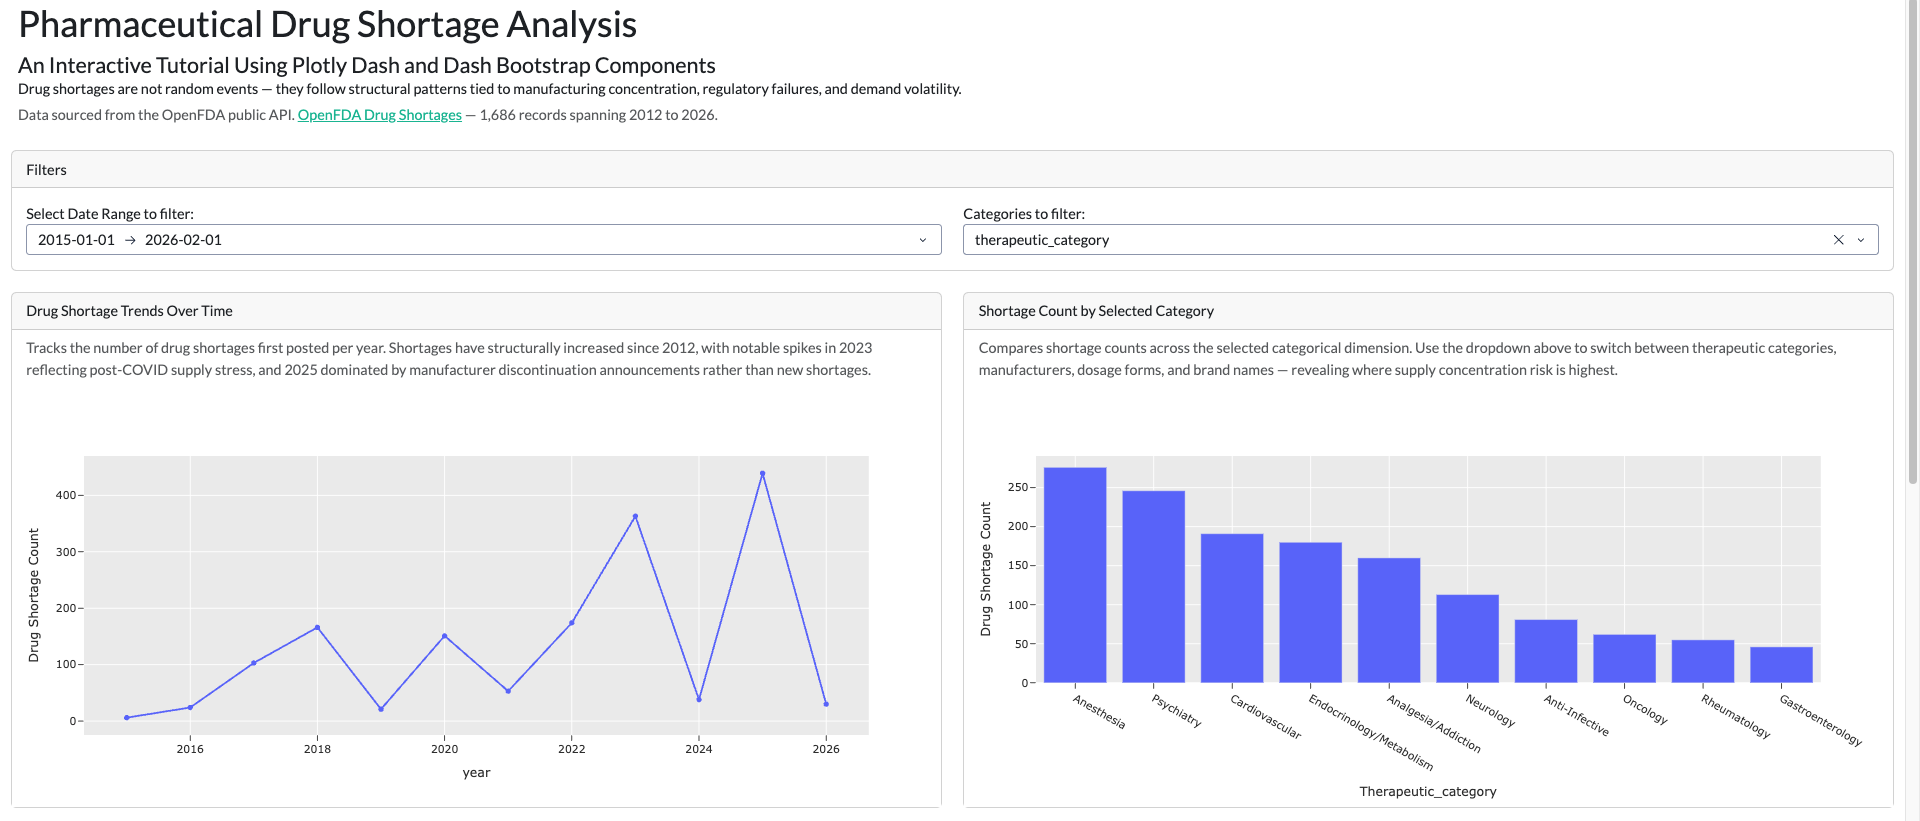

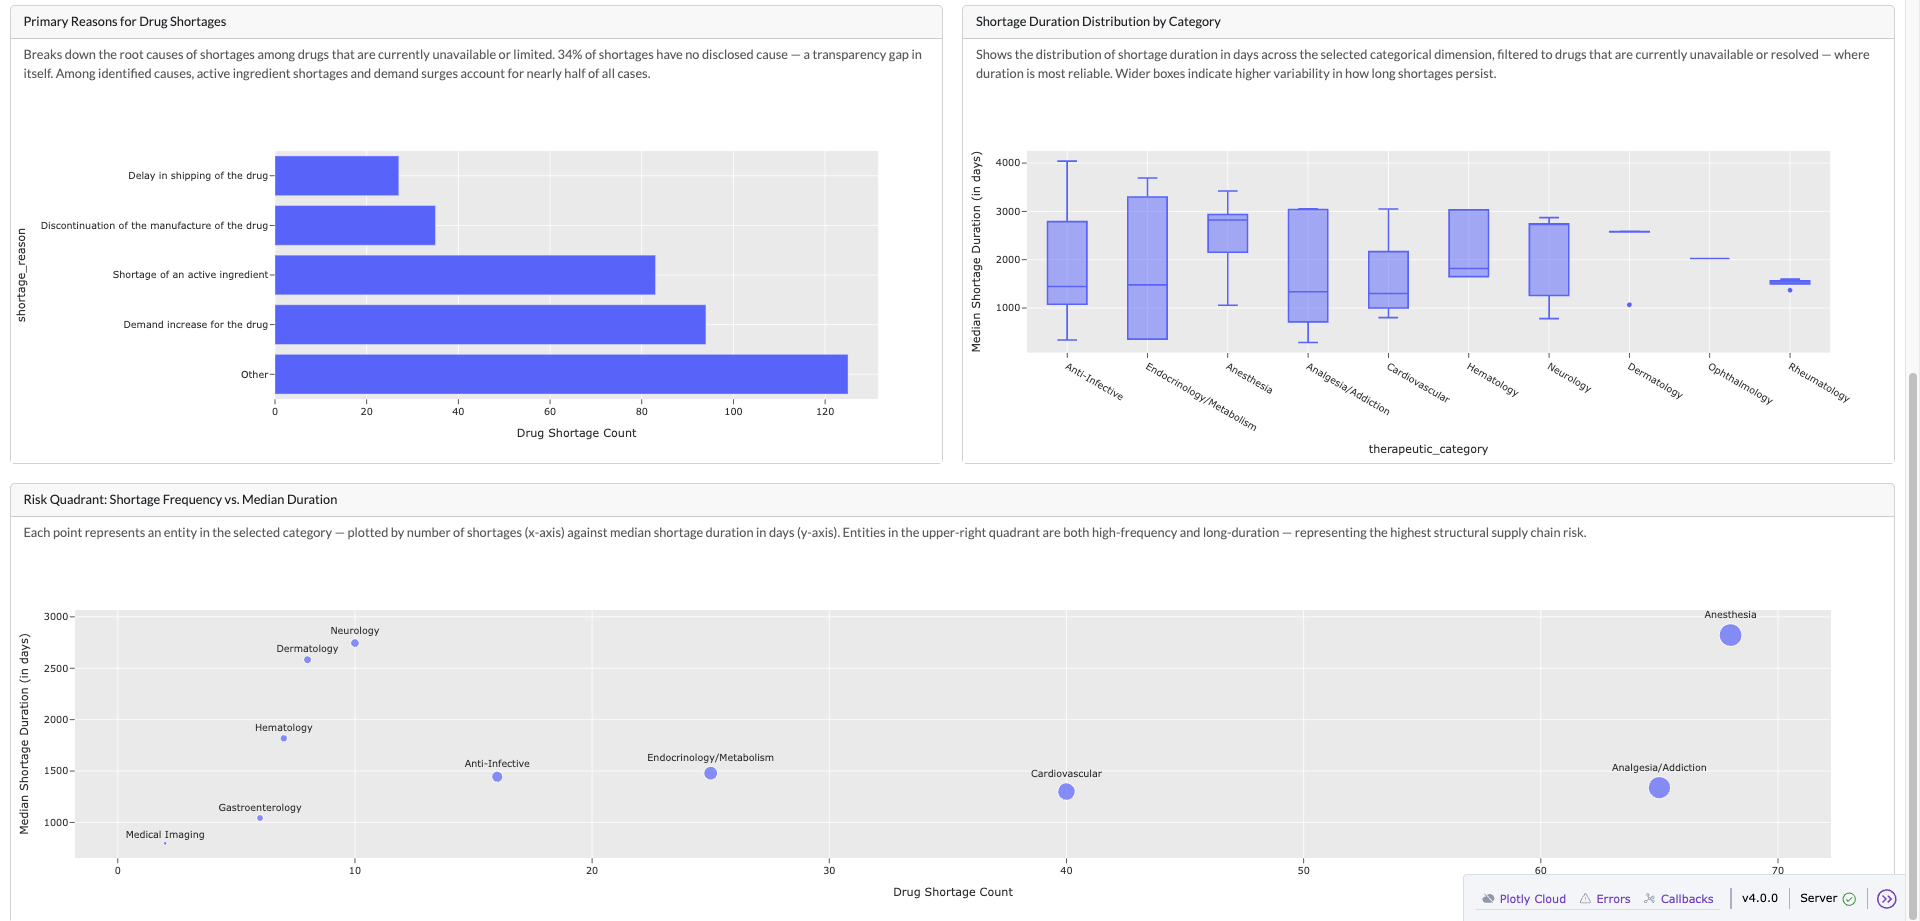

## 5. Deployment Instructions
### 5.1 Running Locally

1. Clone the repository and navigate to the project directory
2. Create a virtual environment: `python -m venv venv`
3. Activate the environment:
   - Mac/Linux: `source venv/bin/activate`
   - Windows: `venv\Scripts\activate`
4. Install dependencies: `pip install -r requirements.txt`
5. Open `notebooks/PharmaSupplyChainDashboard.ipynb` in Jupyter
6. Run all cells top to bottom
7. The dashboard launches automatically at `http://127.0.0.1:8050/`


### 5.2 Deploying to Render.com
[Step by step — what files are needed, what to configure]

### 5.3 Live Dashboard
[Link once deployed]
